In [ ]:
"""
=============================================================================
BORING BAR — PARAMETER 1 : CAVITY POSITION FROM FREE END
=============================================================================

DEFINITION
──────────
  L_free  =  distance from the FREE END of the bar to the START of the cavity
           =  length of the solid tip (Section 5)
           =  L_total − L1 − L2 − L3 − L4

  Measuring from the FREE END is the physically natural choice for a boring
  bar because:
    • The machining operation occurs at the free end
    • The designer asks: "how far back from the cutting edge is the damper?"
    • Small L_free → cavity near tip → large ψ(z_d) → efficient energy transfer
    • Large L_free → cavity near fixed end → small ψ(z_d) → poor damping

  L_free range:  L5_min (15 mm)  to  L_total − L1 − L2 − L4  (130 mm)
  Equivalently:  L3 = L_total − L1 − L2 − L4 − L_free  varies 0 → 115 mm

GEOMETRY — 5 sections
  Sec 1 [0,       L1]          : hollow flange  D1=63 mm, di=20 mm
  Sec 2 [L1,      L1+L2]       : taper          D1 → D_main, di=20 mm
  Sec 3 [L1+L2,   L1+L2+L3]   : hollow shaft   D_main=50 mm, di=20 mm
  Sec 4 [L1+L2+L3, …+L4]      : cavity         D_main=50 mm, di=44 mm
  Sec 5 [L_total−L_free, L_total]: solid tip    D_main=50 mm  ← L_free swept

PHYSICS (fully non-zero speed)
  • 5-section Euler-Bernoulli characteristic equation (20×20)
  • Single-mode modal projection with ALL rotational effects (Eq. 28):
    Coriolis · Gyroscopic · Centrifugal · Rotational inertia
  • Speed-dependent FRF rebuilt at every pocket speed
  • Budak-Altintas pocket-speed stability lobe algorithm
  • Den Hartog optimal tuning at each position
  • Paper-optimal tuning (optimised kd, cd) at each position

RESULTS
  Every plot axis labels the primary physical parameter L_free [mm]
  with the equivalent cavity-centre distance from free end shown on top.
=============================================================================
"""

import numpy as np
from scipy.optimize import brentq, minimize
from scipy.integrate import quad
from scipy.linalg import svd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from datetime import datetime
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

Mounted at /content/drive


Memorisation in Drive

In [ ]:
# ==========================================================
# PERSISTENT CACHE (COLAB + GOOGLE DRIVE)
# ==========================================================

import os
import json
import pickle
import hashlib
from pathlib import Path
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/BoringBar_Project")

CACHE_DIR = BASE_DIR / "Cache"
PLOT_DIR = BASE_DIR / "Plots"
RESULT_DIR = BASE_DIR / "Results"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


def make_case_hash(params):
    txt = json.dumps(params, sort_keys=True, default=str)
    return hashlib.md5(txt.encode()).hexdigest()

def load_case(params):

    case_id = make_case_hash(params)

    fname = CACHE_DIR / f"{case_id}.pkl"

    if fname.exists():

        with open(fname, "rb") as f:
            data = pickle.load(f)

        print(f"✓ Cache hit : {case_id}")

        return data

    return None


def save_case(params, results):

    case_id = make_case_hash(params)

    fname = CACHE_DIR / f"{case_id}.pkl"

    with open(fname, "wb") as f:
        pickle.dump(results, f)

    print(f"✓ Saved : {case_id}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.  CONSTANTS
# ═══════════════════════════════════════════════════════════════════════════

E_body    = 280e9              # Pa
rho_body  = 7850.0 * 1.2      # kg/m³
rho_WC    = 14_500.0           # kg/m³  (tungsten-carbide damper)
zeta_str  = 0.01               # structural damping ratio (1 %)
zeta_oil  = 0.30               # oil/spring damping ratio

L_total   = 0.400              # m  total bar length
D1_out    = 0.063              # m  flange outer dia
D_main    = 0.050              # m  main shaft outer dia
di_body   = 0.020              # m  inner dia of hollow sections 1-2-3
di_cav    = 0.044              # m  cavity inner dia (3 mm wall)
wall_cav  = (D_main - di_cav) / 2     # 3 mm
L1        = 0.040              # m  flange length
L2        = 0.030              # m  taper length
L4        = 0.100              # m  cavity length (fixed)
L5_MIN    = 0.150              # m  minimum solid-tip length
GAP_RAD   = 0.001              # m  damper–cavity radial gap
CLR_AX    = 0.010              # m  axial clearance (both ends)

# Parameter 1 sweep: L_free = L5 (distance from free end to cavity start)
L_FREE_MIN = L5_MIN
L_FREE_MAX = L_total - L1 - L2 - L4     # 0.130 m = 130 mm
N_POS      = 12                           # number of positions to evaluate
L_free_arr = np.linspace(L_FREE_MIN, L_FREE_MAX, N_POS)

# Cutting parameters
Nt  = 2;  Ktc = 2000e6;  Krc = 500e6;  ratio_kr = Krc / Ktc

# Speed grids
N_grid     = np.linspace(100, 6000, 400)
speeds_plot= np.linspace(0, 6000, 200)

#SAVE = "/mnt/user-data/outputs"

print("=" * 70)
print("BORING BAR — PARAMETER 1: CAVITY POSITION FROM FREE END")
print("=" * 70)
print(f"  L_free (= solid tip length) range: "
      f"{L_FREE_MIN*1e3:.0f} – {L_FREE_MAX*1e3:.0f} mm  ({N_POS} values)")
print(f"  Equivalent L3 range: "
      f"{(L_total-L1-L2-L4-L_FREE_MAX)*1e3:.0f} – "
      f"{(L_total-L1-L2-L4-L_FREE_MIN)*1e3:.0f} mm")
print(f"  Cavity centre distance from free end: "
      f"{(L_FREE_MIN+L4/2)*1e3:.0f} – {(L_FREE_MAX+L4/2)*1e3:.0f} mm")

BORING BAR — PARAMETER 1: CAVITY POSITION FROM FREE END
  L_free (= solid tip length) range: 150 – 230 mm  (12 values)
  Equivalent L3 range: 0 – 80 mm
  Cavity centre distance from free end: 200 – 280 mm


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.  CROSS-SECTION AND MATERIAL ARRAYS
# ═══════════════════════════════════════════════════════════════════════════

def xsec(D_out, d_in=0.0):
    ro, ri = D_out/2, d_in/2
    A  = np.pi * (ro**2 - ri**2)
    I  = np.pi * (ro**4 - ri**4) / 4
    Ip = np.pi * (ro**4 - ri**4) / 2
    return A, I, Ip

A1, I1, Ip1 = xsec(D1_out, di_body)
A3, I3, Ip3 = xsec(D_main, di_body)
A4, I4, Ip4 = xsec(D_main, di_cav)
A5, I5, Ip5 = xsec(D_main, 0.0)

_fr = np.linspace(0, 1, 300)
A2  = np.mean([xsec(D1_out + (D_main-D1_out)*f, di_body)[0] for f in _fr])
I2  = np.mean([xsec(D1_out + (D_main-D1_out)*f, di_body)[1] for f in _fr])
Ip2 = np.mean([xsec(D1_out + (D_main-D1_out)*f, di_body)[2] for f in _fr])

# Fixed section arrays (section 4 and 5 properties are constant for param-1 sweep)
EI_fix   = [E_body*I1,  E_body*I2,  E_body*I3,  E_body*I4,  E_body*I5]
rhoA_fix = [rho_body*A1, rho_body*A2, rho_body*A3, rho_body*A4, rho_body*A5]
rhoI_fix = [rho_body*I1, rho_body*I2, rho_body*I3, rho_body*I4, rho_body*I5]
rhoIp_fix= [rho_body*Ip1,rho_body*Ip2,rho_body*Ip3,rho_body*Ip4,rho_body*Ip5]
c_fix    = np.sqrt(np.array(EI_fix) / np.array(rhoA_fix))

# Damper mass (fixed geometry, always same for all positions)
d_damp  = di_cav - 2 * GAP_RAD      # 42 mm
L_damp  = L4 - CLR_AX               # 90 mm
A_damp  = np.pi * (d_damp/2)**2
md      = rho_WC * A_damp * L_damp
print(f"\n  Damper mass md = {md:.4f} kg  (WC, ∅{d_damp*1e3:.0f}mm × {L_damp*1e3:.0f}mm)")


  Damper mass md = 1.8080 kg  (WC, ∅42mm × 90mm)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.  BASIS FUNCTIONS AND CHARACTERISTIC MATRIX
# ═══════════════════════════════════════════════════════════════════════════

def P(b, z):
    return np.array([np.cos(b*z),  np.cosh(b*z),  np.sin(b*z),  np.sinh(b*z)])
def dP(b, z):
    return np.array([-b*np.sin(b*z), b*np.sinh(b*z), b*np.cos(b*z), b*np.cosh(b*z)])
def d2P(b, z):
    return np.array([-b**2*np.cos(b*z), b**2*np.cosh(b*z),
                     -b**2*np.sin(b*z), b**2*np.sinh(b*z)])
def d3P(b, z):
    return np.array([b**3*np.sin(b*z),  b**3*np.sinh(b*z),
                    -b**3*np.cos(b*z),  b**3*np.cosh(b*z)])


def section_bounds(L_free):
    """Return [z0..z5] for given L_free (= L5)."""
    L5 = L_free
    L3 = L_total - L1 - L2 - L4 - L5
    return [0, L1, L1+L2, L1+L2+L3, L1+L2+L3+L4, L_total], L3, L5


def char_mat_5s(omega, zb):
    """20×20 characteristic matrix for given section boundaries zb."""
    bs = np.sqrt(omega / c_fix)
    M  = np.zeros((20, 20));  r = 0
    # Fixed-end BCs
    M[r, 0:4]  = P(bs[0], zb[0]);   r += 1
    M[r, 0:4]  = dP(bs[0], zb[0]);  r += 1
    # Free-end BCs
    M[r,16:20] = EI_fix[4] * d2P(bs[4], zb[5]);  r += 1
    M[r,16:20] = EI_fix[4] * d3P(bs[4], zb[5]);  r += 1
    # Interface conditions at the 4 internal interfaces
    for k in range(4):
        z  = zb[k+1]
        bl = bs[k];  br = bs[k+1]
        EIl= EI_fix[k];  EIr = EI_fix[k+1]
        cl = 4*k;  cr = 4*(k+1)
        M[r, cl:cl+4] =       P(bl, z);  M[r, cr:cr+4] =      -P(br, z);  r += 1
        M[r, cl:cl+4] =      dP(bl, z);  M[r, cr:cr+4] =     -dP(br, z);  r += 1
        M[r, cl:cl+4] = EIl*d2P(bl, z);  M[r, cr:cr+4] = -EIr*d2P(br, z); r += 1
        M[r, cl:cl+4] = EIl*d3P(bl, z);  M[r, cr:cr+4] = -EIr*d3P(br, z); r += 1
    return M


def sdet_sign(omega, zb):
    try:
        s, _ = np.linalg.slogdet(char_mat_5s(omega, zb))
        return float(s)
    except Exception:
        return 0.0


def find_wn1(zb, n_scan=80_000):
    """Find first natural frequency (rad/s) by scanning omega."""
    scan  = np.linspace(200.0, 50_000.0, n_scan)
    signs = np.array([sdet_sign(om, zb) for om in scan])
    for i in range(len(signs) - 1):
        if signs[i]*signs[i+1] < 0 and signs[i] != 0 and signs[i+1] != 0:
            try:
                return brentq(lambda o: sdet_sign(o, zb),
                              scan[i], scan[i+1], xtol=0.5)
            except Exception:
                pass
    return None

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.  MODE SHAPE AND MODAL INTEGRALS
# ═══════════════════════════════════════════════════════════════════════════

def get_mode(wn1, zb):
    """
    Return psi(z), dpsi(z) normalised so psi(L_total)=1,
    plus modal integrals Mm, Rii, Gii.
    """
    bs = np.sqrt(wn1 / c_fix)
    _, _, Vh = svd(char_mat_5s(wn1, zb))
    C_ = Vh[-1]

    def _raw(z):
        if   z <= zb[1]: return C_[ 0: 4] @ P(bs[0], z)
        elif z <= zb[2]: return C_[ 4: 8] @ P(bs[1], z)
        elif z <= zb[3]: return C_[ 8:12] @ P(bs[2], z)
        elif z <= zb[4]: return C_[12:16] @ P(bs[3], z)
        else:            return C_[16:20] @ P(bs[4], z)

    def _draw(z):
        if   z <= zb[1]: return C_[ 0: 4] @ dP(bs[0], z)
        elif z <= zb[2]: return C_[ 4: 8] @ dP(bs[1], z)
        elif z <= zb[3]: return C_[ 8:12] @ dP(bs[2], z)
        elif z <= zb[4]: return C_[12:16] @ dP(bs[3], z)
        else:            return C_[16:20] @ dP(bs[4], z)

    sc   = _raw(L_total)
    psi  = lambda z: _raw(z) / sc
    dpsi = lambda z: _draw(z) / sc

    Mm  = sum(quad(lambda z: rhoA_fix[k] * psi(z)**2,  zb[k], zb[k+1], limit=150)[0]
              for k in range(5))
    Rii = sum(quad(lambda z: rhoI_fix[k] * dpsi(z)**2, zb[k], zb[k+1], limit=150)[0]
              for k in range(5))
    Gii = sum(quad(lambda z: rhoIp_fix[k]* dpsi(z)**2, zb[k], zb[k+1], limit=150)[0]
              for k in range(5))
    return psi, dpsi, Mm, Rii, Gii

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.  TUNING: DEN HARTOG AND PAPER-OPTIMAL
# ═══════════════════════════════════════════════════════════════════════════

def den_hartog(Mm, wn1):
    mu       = md / Mm
    wd       = wn1 / (1.0 + mu)
    zeta_dh  = np.sqrt(3.0*mu / (8.0*(1.0+mu)))
    kd       = md * wd**2
    cd       = 2.0 * zeta_dh * md * wd
    return kd, cd, mu, zeta_dh

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 6.  SYSTEM MATRICES — all rotational effects (Eq. 28)
# ═══════════════════════════════════════════════════════════════════════════

def build_4x4(Omega, Mm, Rii, Gii, Km, Cm, PSI_zd, kd, cd):
    M11   = Mm + Rii
    K11   = Km - Omega**2 * Mm
    K_abs = kd - Omega**2 * md
    Cor   = 2*Omega*Mm;   Gyr = 2*Omega*Gii
    C_off = Cor - Gyr;    Ca  = 2*Omega*md
    M = np.diag([M11, md, M11, md])
    K = np.array([[K11+kd*PSI_zd**2, -kd*PSI_zd, 0, 0],
                  [-kd*PSI_zd, K_abs, 0, 0],
                  [0, 0, K11+kd*PSI_zd**2, -kd*PSI_zd],
                  [0, 0, -kd*PSI_zd, K_abs]])
    D = np.array([[Cm+cd*PSI_zd**2, -cd*PSI_zd,  C_off, 0],
                  [-cd*PSI_zd,       cd,          0,     Ca],
                  [-C_off, 0, Cm+cd*PSI_zd**2, -cd*PSI_zd],
                  [0, -Ca, -cd*PSI_zd, cd]])
    return M, D, K


def build_2x2(Omega, Mm, Rii, Gii, Km, Cm):
    M11  = Mm + Rii;  K11 = Km - Omega**2*Mm
    Coff = 2*Omega*Mm - 2*Omega*Gii
    M = np.diag([M11, M11]);  K = np.diag([K11, K11])
    D = np.array([[Cm,  Coff], [-Coff, Cm]])
    return M, D, K

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.  FRF, DIRECTIONAL COEFFICIENTS, STABILITY LOBES
# ═══════════════════════════════════════════════════════════════════════════

def frf_at_wc(wc, M, D, K, PSI_zf):
    n = M.shape[0];  nb = n//2
    fx = np.zeros(n);  fx[0]  = PSI_zf
    fy = np.zeros(n);  fy[nb] = PSI_zf
    Z  = -wc**2*M + 1j*wc*D + K
    try:
        H = np.linalg.solve(Z, np.column_stack([fx, fy]))
        return PSI_zf*H[0,0], PSI_zf*H[0,1]
    except np.linalg.LinAlgError:
        return 0j, 0j


def dir_coeffs():
    phi = np.linspace(0, np.pi/2, 80_000)   # 50 % up-milling
    r   = ratio_kr
    return (np.trapezoid(np.sin(phi)*(-np.cos(phi)-r*np.sin(phi)), phi),
            np.trapezoid(np.cos(phi)*(-np.cos(phi)-r*np.sin(phi)), phi),
            np.trapezoid(np.sin(phi)*(np.sin(phi) -r*np.cos(phi)), phi),
            np.trapezoid(np.cos(phi)*(np.sin(phi) -r*np.cos(phi)), phi))

AXX, AXY, AYX, AYY = dir_coeffs()


def pocket_speed_lobes(Mm, Rii, Gii, Km, Cm, PSI_zd, PSI_zf, wn1,
                       kd, cd, speed_dep=True,
                       wc_pts=4000, max_lobe=20, Nmin=100, Nmax=6100):
    """
    Budak-Altintas pocket-speed stability lobe algorithm.
    speed_dep=True  → FRF rebuilt at every pocket speed (proposed method).
    speed_dep=False → FRF always at Ω=0 (classical zero-speed method).
    Returns (N_rpm, alim_mm, fc_hz).
    """
    wc_arr = np.linspace(0.3*wn1, 2.5*wn1, wc_pts)
    M0, D0, K0 = build_4x4(0.0, Mm, Rii, Gii, Km, Cm, PSI_zd, kd, cd)
    N_out = [];  a_out = [];  fc_out = []

    for wc in wc_arr:
        fc  = wc / (2*np.pi)
        hxx, hxy = frf_at_wc(wc, M0, D0, K0, PSI_zf)
        hyy = hxx;  hyx = hxy
        h11 = AXX*hxx+AXY*hyx;  h12 = AXX*hxy+AXY*hyy
        h21 = AYX*hxx+AYY*hyx;  h22 = AYX*hxy+AYY*hyy
        tr  = h11+h22;  dv = h11*h22 - h12*h21
        if abs(dv) < 1e-60:
            continue
        disc = tr**2 - 4*dv;  sq = np.sqrt(disc + 0j)
        for lam in [(-tr+sq)/(2*dv), (-tr-sq)/(2*dv)]:
            rl = np.real(lam);  il = np.imag(lam)
            if rl >= 0:
                continue
            al = -2*np.pi*rl / (Nt*Ktc) * (1 + (il/rl)**2)
            if al <= 0 or al > 0.020:
                break
            kappa   = il / rl
            epsilon = np.pi - 2*np.arctan(kappa)
            for k in range(max_lobe + 1):
                denom = k + epsilon/(2*np.pi)
                if denom <= 0:
                    continue
                Np = 60*fc / (Nt*denom)
                if not (Nmin <= Np <= Nmax):
                    continue
                if speed_dep:
                    Om = Np * 2*np.pi/60
                    Mp, Dp, Kp = build_4x4(Om, Mm, Rii, Gii, Km, Cm, PSI_zd, kd, cd)
                    hxx2, hxy2 = frf_at_wc(wc, Mp, Dp, Kp, PSI_zf)
                    hyy2=hxx2; hyx2=hxy2
                    h11_=AXX*hxx2+AXY*hyx2; h12_=AXX*hxy2+AXY*hyy2
                    h21_=AYX*hxx2+AYY*hyx2; h22_=AYX*hxy2+AYY*hyy2
                    tr_=h11_+h22_; dv_=h11_*h22_-h12_*h21_
                    if abs(dv_) < 1e-60:
                        continue
                    disc_=tr_**2-4*dv_; sq_=np.sqrt(disc_+0j)
                    for lam_ in [(-tr_+sq_)/(2*dv_), (-tr_-sq_)/(2*dv_)]:
                        rl_=np.real(lam_); il_=np.imag(lam_)
                        if rl_ < 0:
                            al_ = -2*np.pi*rl_/(Nt*Ktc)*(1+(il_/rl_)**2)
                            if al_ > 0:
                                kap2=il_/rl_; eps2=np.pi-2*np.arctan(kap2)
                                den2=k+eps2/(2*np.pi)
                                if den2 > 0:
                                    N2 = 60*fc/(Nt*den2)
                                    if Nmin <= N2 <= Nmax:
                                        N_out.append(N2)
                                        a_out.append(al_*1000)
                                        fc_out.append(fc)
                            break
                else:
                    N_out.append(Np)
                    a_out.append(al * 1000)
                    fc_out.append(fc)
            break
    return np.array(N_out), np.array(a_out), np.array(fc_out)


def noabs_lobes(Mm, Rii, Gii, Km, Cm, PSI_zf, wn1,
                wc_pts=3000, max_lobe=20, Nmin=100, Nmax=6100):
    """Stability lobes without absorber (zero-speed FRF)."""
    wc_arr = np.linspace(0.3*wn1, 2.5*wn1, wc_pts)
    M0, D0, K0 = build_2x2(0.0, Mm, Rii, Gii, Km, Cm)
    N_out = [];  a_out = [];  fc_out = []
    for wc in wc_arr:
        fc = wc/(2*np.pi)
        hxx, hxy = frf_at_wc(wc, M0, D0, K0, PSI_zf)
        hyy=hxx; hyx=hxy
        h11=AXX*hxx+AXY*hyx; h12=AXX*hxy+AXY*hyy
        h21=AYX*hxx+AYY*hyx; h22=AYX*hxy+AYY*hyy
        tr=h11+h22; dv=h11*h22-h12*h21
        if abs(dv)<1e-60: continue
        disc=tr**2-4*dv; sq=np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*dv),(-tr-sq)/(2*dv)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl<0:
                al=-2*np.pi*rl/(Nt*Ktc)*(1+(il/rl)**2)
                if 0<al<0.020:
                    kp=il/rl; ep=np.pi-2*np.arctan(kp)
                    for k in range(max_lobe+1):
                        dn=k+ep/(2*np.pi)
                        if dn>0:
                            Np=60*fc/(Nt*dn)
                            if Nmin<=Np<=Nmax: N_out.append(Np); a_out.append(al*1000); fc_out.append(fc)
                break
    return np.array(N_out), np.array(a_out), np.array(fc_out)


def lower_env(N, a, Ng, win=100.0):
    env = np.full(len(Ng), np.nan)
    for i, Ngi in enumerate(Ng):
        mask = np.abs(N - Ngi) < win
        if mask.sum() > 0:
            env[i] = a[mask].min()
    return env

In [ ]:
#----------------------------------------------
# Objective function optimised for kd and cd
#----------------------------------------------
speeds_opt_rpm = np.linspace(0, 6000, 13)  # 12 steps



def obj_func(log_params, md_, case, KD_LO, KD_HI, CD_LO, CD_HI):
    OBJ_CACHE={}
    kd_ = 10**log_params[0]; cd_ = 10**log_params[1]
    if kd_ < KD_LO or kd_ > KD_HI or cd_ < CD_LO or cd_ > CD_HI:
        return 1e10
    alim_sum = 0
    #for rpm in speeds_opt_rpm:
        #Omega = rpm*2*np.pi/60
    N_dhS, a_dhS, _ = pocket_speed_lobes(
    Mm, Rii, Gii, Km, Cm, PSI_zd, PSI_zf, wn1,
    kd_,cd_, speed_dep=True, wc_pts=3500)
    alim_sum = sum(a_dhS)
    return -np.sqrt(alim_sum/len(speeds_opt_rpm))

def optimize_absorber(md_, case, kd_dh1, cd_dh1, KD_LO, KD_HI, CD_LO, CD_HI):
    x0 = [np.log10(kd_dh1), np.log10(cd_dh1)]
    res = minimize(obj_func, x0, args=(md_, case, KD_LO, KD_HI, CD_LO, CD_HI), method='Nelder-Mead',
                   options={'xatol':0.05,'fatol':1e-9,'maxiter':200,'maxfev':600})
    kd_opt = float(np.clip(10**res.x[0], KD_LO, KD_HI))
    cd_opt = float(np.clip(10**res.x[1], CD_LO, CD_HI))
    return kd_opt, cd_opt

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.  MAIN POSITION SWEEP
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'L_free':>8} {'L3':>6} {'zd_ctr':>7} {'zd/L':>5} {'fn1':>7} "
      f"{'Mm':>7} {'PSI_zd':>7} {'μ':>6} {'kd_op':>9} {'cd_op':>7} "
      f"{'al_na':>7} {'al_op':>7} {'ratio':>6}")
print("-"*105)

results = []

for L_free in L_free_arr:
    case_params = {
    "L_free": float(L_free),
    "E_body": E_body,
    "rho_body": rho_body,
    "rho_WC": rho_WC,
    "L_total": L_total,
    "D1_out": D1_out,
    "D_main": D_main,
    "di_body": di_body,
    "di_cav": di_cav,
    "L1": L1,
    "L2": L2,
    "L4": L4,
    "Nt": Nt,
    "Ktc": Ktc,
    "Krc": Krc
    }

    cached = None # Initialize cached to None
    try:
        cached = load_case(case_params)
    except EOFError:
        print(f"Cache file for L_free={L_free*1000:.1f} mm is corrupted (EOFError). Recomputing.")
        cached = None # Treat as cache miss
    except Exception as e:
        print(f"An unexpected error occurred while loading cache for L_free={L_free*1000:.1f} mm: {e}. Recomputing.")
        cached = None # Treat as cache miss

    if cached is not None:
        results.append(cached)
        print(
            f"Using cached result for "
            f"L_free={L_free*1000:.1f} mm"
        )
        continue

    zb, L3, L5 = section_bounds(L_free)

    # ── natural frequency
    wn1 = find_wn1(zb)
    if wn1 is None:
        print(f"  {L_free*1e3:6.1f}mm  L3={L3*1e3:.0f}mm  NO ROOT — skipping")
        continue
    fn1 = wn1 / (2*np.pi)

    # ── mode shape and integrals
    psi, dpsi, Mm, Rii, Gii = get_mode(wn1, zb)
    Km  = wn1**2 * Mm
    Cm  = 2*zeta_str * wn1 * Mm

    zd     = (zb[3] + zb[4]) / 2.0
    PSI_zd = psi(zd)
    PSI_zf = psi(L_total)          # = 1.0

    # ── tuning
    kd_dh1, cd_dh1, mu1, zeta_dh1 = den_hartog(Mm,wn1)

    # Adaptive bounds — scale from Den Hartog so they make physical sense
    # for this particular boring bar geometry
    KD_LO = max(kd_dh1 * 0.05, 1e3)
    KD_HI = min(kd_dh1 * 20.0, 1e9)
    CD_LO = max(cd_dh1 * 0.02, 5.0)
    CD_HI = min(cd_dh1 * 10.0, 100_000.0)

    kd_dh, cd_dh = optimize_absorber(Mm, wn1, kd_dh1, cd_dh1, KD_LO, KD_HI, CD_LO, CD_HI)

    # ── stability: no absorber (reference)
    N_na, a_na, _ = noabs_lobes(Mm, Rii, Gii, Km, Cm, PSI_zf, wn1)
    env_na = lower_env(N_na, a_na, N_grid)
    alim_na = np.nanmin(env_na) if not np.all(np.isnan(env_na)) else 0.0

    # ── stability: DH absorber, zero-speed FRF (classical)
    N_dh0, a_dh0, _ = pocket_speed_lobes(
        Mm, Rii, Gii, Km, Cm, PSI_zd, PSI_zf, wn1,
        kd_dh, cd_dh, speed_dep=False, wc_pts=3000)
    env_dh0 = lower_env(N_dh0, a_dh0, N_grid)
    alim_dh0 = np.nanmin(env_dh0) if not np.all(np.isnan(env_dh0)) else 0.0

    # ── stability: DH absorber, speed-dependent FRF (proposed)
    N_dhS, a_dhS, _ = pocket_speed_lobes(
        Mm, Rii, Gii, Km, Cm, PSI_zd, PSI_zf, wn1,
        kd_dh, cd_dh, speed_dep=True, wc_pts=3500)
    env_dhS = lower_env(N_dhS, a_dhS, N_grid)
    alim_dhS = np.nanmin(env_dhS) if not np.all(np.isnan(env_dhS)) else 0.0

    ratio_dh0 = alim_dh0 / alim_na if alim_na > 0 else 0.0
    ratio_dhS = alim_dhS / alim_na if alim_na > 0 else 0.0

    case_result = dict(
    L_free=L_free,
    L3=L3,
    L5=L5,
    zd=zd,
    fn1=fn1,
    wn1=wn1,
    Mm=Mm,
    Rii=Rii,
    Gii=Gii,
    Km=Km,
    Cm=Cm,
    PSI_zd=PSI_zd,
    PSI_zf=PSI_zf,
    zb=zb,
    kd_dh=kd_dh,
    cd_dh=cd_dh,
    mu=mu1,
    zeta_dh=zeta_dh1,
    alim_na=alim_na,
    alim_dh0=alim_dh0,
    alim_dhS=alim_dhS,
    ratio_dh0=ratio_dh0,
    ratio_dhS=ratio_dhS,
    env_na=env_na,
    env_dh0=env_dh0,
    env_dhS=env_dhS
    )

    save_case(case_params, case_result)

    results.append(case_result)

    dist_from_free = L_free + L4/2   # centre of cavity to free end
    print(f"  {L_free*1e3:6.1f}  {L3*1e3:6.0f}  {zd*1e3:7.0f}  "
          f"{zd/L_total:5.3f}  {fn1:7.1f}  {Mm:7.4f}  {PSI_zd:7.4f}  "
          f" {kd_dh/1e6:9.4f}  {cd_dh:7.1f}  "
          f"{alim_na:7.4f}  {alim_dhS:7.4f}  {ratio_dhS:6.2f}×")

# ── best position
best   = max(results, key=lambda r: r['ratio_dhS'])
worst  = min(results, key=lambda r: r['ratio_dhS'])
L_free_best = best['L_free']

print(f"\n  ★ OPTIMUM (speed-dep. DH): L_free = {L_free_best*1e3:.1f} mm  "
      f"→  {best['ratio_dhS']:.2f}×  |  fn1={best['fn1']:.1f} Hz")
print(f"  ★ WORST :                  L_free = {worst['L_free']*1e3:.1f} mm  "
      f"→  {worst['ratio_dhS']:.2f}×")


  L_free     L3  zd_ctr  zd/L     fn1      Mm  PSI_zd      μ     kd_op   cd_op   al_na   al_op  ratio
---------------------------------------------------------------------------------------------------------
✓ Cache hit : cf488c635816d7196336963ed307f8a6
Using cached result for L_free=150.0 mm
✓ Cache hit : 26bf3874ee2ee6c28adca5544c98883d
Using cached result for L_free=157.3 mm
✓ Cache hit : ad6973d0954012c8bee1747b4105f32f
Using cached result for L_free=164.5 mm
✓ Cache hit : 788ef2a1b5887dc6a4ad0d1c150c0045
Using cached result for L_free=171.8 mm
✓ Cache hit : ce8111391998b17912cd710fcf8b2cc1
Using cached result for L_free=179.1 mm
✓ Cache hit : 6e81cb5139781e1e01f594ec5ba33362
Using cached result for L_free=186.4 mm
✓ Cache hit : 0b81b567a8aba90b6ff59c9ff232da9c
Using cached result for L_free=193.6 mm
✓ Cache hit : 66f4c83f19b74f79564effbc9c9d1f76
Using cached result for L_free=200.9 mm
✓ Cache hit : 1f6bf02c3d747120220097c500eca236
Using cached result for L_free=208.2 mm
✓ Cache 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 9.  FORCE-EFFECT LOBES AT BEST POSITION
# ═══════════════════════════════════════════════════════════════════════════
r = best

def lobes_with_flags(cor, gyro, cent, ri, spd_dep):
    Rii_u = r['Rii'] if ri else 0.0
    def mat_fn(Om):
        M11=r['Mm']+Rii_u; K11=r['Km']-(Om**2*r['Mm'] if cent else 0)
        K_a=r['kd_dh']-(Om**2*md if cent else 0)
        Cof=(2*Om*r['Mm'] if cor else 0)-(2*Om*r['Gii'] if gyro else 0)
        Ca=(2*Om*md if cor else 0)
        M=np.diag([M11,md,M11,md])
        K=np.array([[K11+r['kd_dh']*r['PSI_zd']**2,-r['kd_dh']*r['PSI_zd'],0,0],
                    [-r['kd_dh']*r['PSI_zd'],K_a,0,0],
                    [0,0,K11+r['kd_dh']*r['PSI_zd']**2,-r['kd_dh']*r['PSI_zd']],
                    [0,0,-r['kd_dh']*r['PSI_zd'],K_a]])
        D=np.array([[r['Cm']+r['cd_dh']*r['PSI_zd']**2,-r['cd_dh']*r['PSI_zd'],Cof,0],
                    [-r['cd_dh']*r['PSI_zd'],r['cd_dh'],0,Ca],
                    [-Cof,0,r['Cm']+r['cd_dh']*r['PSI_zd']**2,-r['cd_dh']*r['PSI_zd']],
                    [0,-Ca,-r['cd_dh']*r['PSI_zd'],r['cd_dh']]])
        return M,D,K
    wc_arr=np.linspace(0.3*r['wn1'],2.5*r['wn1'],3000)
    M0,D0,K0=mat_fn(0.0)
    N_o=[]; a_o=[]
    for wc in wc_arr:
        fc=wc/(2*np.pi)
        hxx,hxy=frf_at_wc(wc,M0,D0,K0,r['PSI_zf']); hyy=hxx; hyx=hxy
        h11=AXX*hxx+AXY*hyx; h12=AXX*hxy+AXY*hyy
        h21=AYX*hxx+AYY*hyx; h22=AYX*hxy+AYY*hyy
        tr=h11+h22; dv=h11*h22-h12*h21
        if abs(dv)<1e-60: continue
        disc=tr**2-4*dv; sq=np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*dv),(-tr-sq)/(2*dv)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl<0:
                al=-2*np.pi*rl/(Nt*Ktc)*(1+(il/rl)**2)
                if 0<al<0.020:
                    kp=il/rl; ep=np.pi-2*np.arctan(kp)
                    for k in range(20):
                        dn=k+ep/(2*np.pi)
                        if dn>0:
                            Np=60*fc/(Nt*dn)
                            if 100<=Np<=6100:
                                if spd_dep:
                                    Om=Np*2*np.pi/60; Mp,Dp,Kp=mat_fn(Om)
                                    hxx2,hxy2=frf_at_wc(wc,Mp,Dp,Kp,r['PSI_zf'])
                                    hyy2=hxx2; hyx2=hxy2
                                    h11_=AXX*hxx2+AXY*hyx2; h12_=AXX*hxy2+AXY*hyy2
                                    h21_=AYX*hxx2+AYY*hyx2; h22_=AYX*hxy2+AYY*hyy2
                                    tr_=h11_+h22_; dv_=h11_*h22_-h12_*h21_
                                    if abs(dv_)<1e-60: continue
                                    disc_=tr_**2-4*dv_; sq_=np.sqrt(disc_+0j)
                                    for lam_ in [(-tr_+sq_)/(2*dv_),(-tr_-sq_)/(2*dv_)]:
                                        rl_=np.real(lam_); il_=np.imag(lam_)
                                        if rl_<0:
                                            al_=-2*np.pi*rl_/(Nt*Ktc)*(1+(il_/rl_)**2)
                                            if al_>0:
                                                kap2=il_/rl_; eps2=np.pi-2*np.arctan(kap2)
                                                den2=k+eps2/(2*np.pi)
                                                if den2>0:
                                                    N2=60*fc/(Nt*den2)
                                                    if 100<=N2<=6100: N_o.append(N2); a_o.append(al_*1000)
                                            break
                                else:
                                    N_o.append(Np); a_o.append(al*1000)
                break
    return lower_env(np.array(N_o),np.array(a_o),N_grid)

print("\nComputing individual force-effect lobes at best position …")
env_cor   = lobes_with_flags(True,  False, False, False, True)
env_gyro  = lobes_with_flags(False, True,  False, False, True)
env_cent  = lobes_with_flags(False, False, True,  False, True)
env_ri    = lobes_with_flags(False, False, False, True,  False)
print("Done.")


Computing individual force-effect lobes at best position …
Done.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.  NATURAL FREQUENCIES vs SPEED AT BEST POSITION
# ═══════════════════════════════════════════════════════════════════════════?/

def nat_freqs_rpm(r_, speeds):
    fw=[]; bw=[]; ab=[]
    for rpm in speeds:
        Om=rpm*2*np.pi/60
        M,D,K=build_4x4(Om,r_['Mm'],r_['Rii'],r_['Gii'],r_['Km'],r_['Cm'],
                         r_['PSI_zd'],r_['kd_dh'],r_['cd_dh'])
        sz=M.shape[0]; A=np.zeros((2*sz,2*sz)); Mi=np.linalg.inv(M)
        A[:sz,:sz]=-Mi@D; A[:sz,sz:]=-Mi@K; A[sz:,:sz]=np.eye(sz)
        evs=np.linalg.eigvals(A)
        fs=sorted(np.abs(evs.imag)/(2*np.pi)); fs=[f for f in fs if f>5]
        dedup=[]
        for f in fs:
            if not dedup or abs(f-dedup[-1])>0.5: dedup.append(f)
        wh=r_['fn1']
        beam=[f for f in dedup if 0.3*wh<f<3.5*wh]
        abm =[f for f in dedup if abs(f-np.sqrt(r_['kd_dh']/md)/(2*np.pi))<300]
        if len(beam)>=2: bw.append(beam[0]); fw.append(beam[-1])
        elif len(beam)==1: bw.append(beam[0]); fw.append(beam[0])
        else: bw.append(np.nan); fw.append(np.nan)
        ab.append(abm[0] if abm else np.nan)
    return np.array(fw), np.array(bw), np.array(ab)

print("Computing natural frequencies vs speed …")
fw_abs, bw_abs, ab_abs = nat_freqs_rpm(best, speeds_plot)
fw_na,  bw_na,  _      = nat_freqs_rpm(
    {**best, 'kd_dh':0.0, 'cd_dh':0.0}, speeds_plot)
print("Done.")

# FRF at selected speeds
freqs_frf  = np.linspace(50, 2.5*best['fn1'], 1000)
frf_speeds = [0, 2000, 4000, 6000]
clrs_frf   = ["#333333","#1A80C4","#27AE60","#E77728"]
FRF_d=[]; FRF_c=[]
for rpm in frf_speeds:
    Om=rpm*2*np.pi/60
    M4,D4,K4=build_4x4(Om,best['Mm'],best['Rii'],best['Gii'],
                        best['Km'],best['Cm'],best['PSI_zd'],
                        best['kd_dh'],best['cd_dh'])
    hp=[frf_at_wc(2*np.pi*f,M4,D4,K4,best['PSI_zf']) for f in freqs_frf]
    FRF_d.append(np.abs([h[0] for h in hp]))
    FRF_c.append(np.abs([h[1] for h in hp]))

Computing natural frequencies vs speed …
Done.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 11.  PLOTTING
# ═══════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "font.family":"DejaVu Sans","font.size":9,"axes.titlesize":9.5,
    "axes.labelsize":9,"xtick.labelsize":8,"ytick.labelsize":8,
    "lines.linewidth":1.6,"figure.dpi":150,
})

cmap_pos = plt.get_cmap("plasma")
n_res    = len(results)
L_free_v = np.array([r_['L_free']*1e3 for r_ in results])
fn1_v    = np.array([r_['fn1']        for r_ in results])
Mm_v     = np.array([r_['Mm']         for r_ in results])
psi_v    = np.array([r_['PSI_zd']     for r_ in results])
mu_v     = np.array([1/r_['kd_dh']-1  for r_ in results])
kd_v     = np.array([r_['kd_dh']/1e6  for r_ in results])
cd_v     = np.array([r_['cd_dh']      for r_ in results])
al_na_v  = np.array([r_['alim_na']    for r_ in results])
al_dh0_v = np.array([r_['alim_dh0']   for r_ in results])
al_dhS_v = np.array([r_['alim_dhS']   for r_ in results])
ratio0_v = np.array([r_['ratio_dh0']  for r_ in results])
ratioS_v = np.array([r_['ratio_dhS']  for r_ in results])
zd_free_v= np.array([(r_['L_free']+L4/2)*1e3 for r_ in results])  # cavity centre dist from free end

KeyError: 'psi_fn'

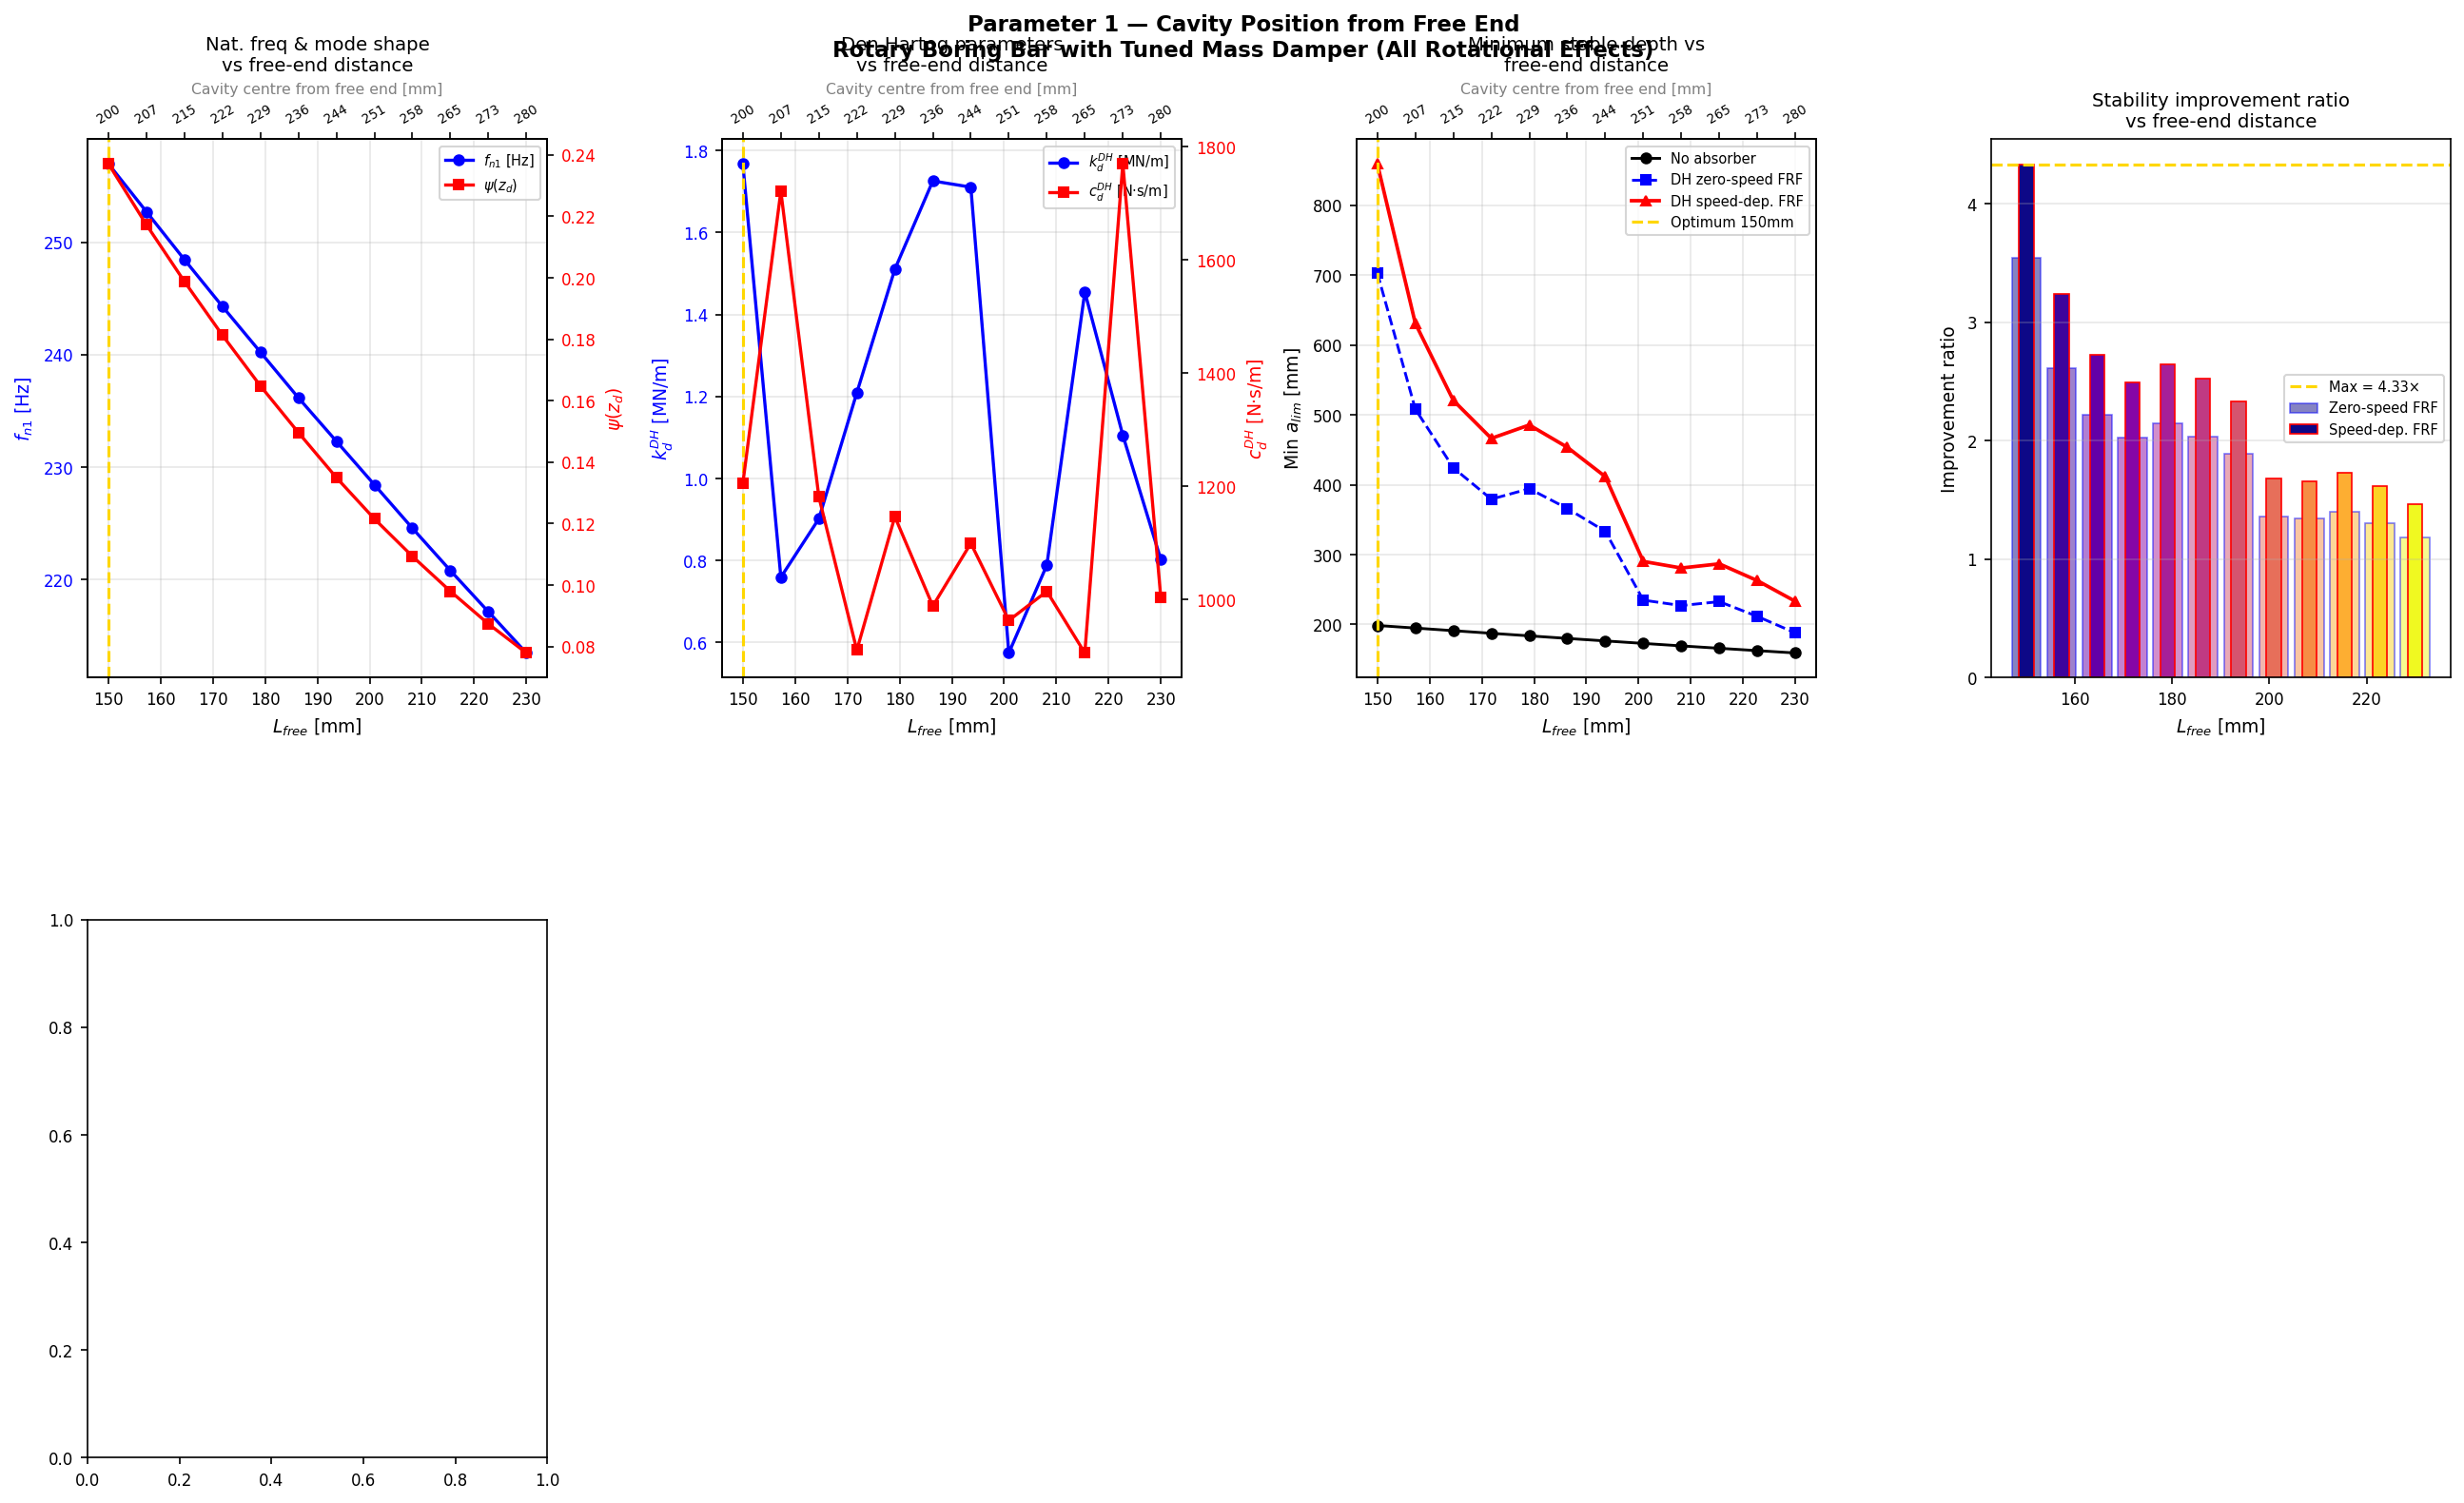

In [ ]:
# ── FIG 1 : position sweep summary ────────────────────────────────────────
fig1 = plt.figure(figsize=(18, 11))
fig1.suptitle(
    "Parameter 1 — Cavity Position from Free End\n"
    "Rotary Boring Bar with Tuned Mass Damper (All Rotational Effects)",
    fontsize=11, fontweight="bold", y=1.00)
gs1 = gridspec.GridSpec(2, 4, figure=fig1, hspace=0.45, wspace=0.38,
                         left=0.05, right=0.97, top=0.92, bottom=0.08)

best['mu']=1/best['kd_dh']-1
best['zeta_dh']=np.sqrt(3.0*best['mu'] / (8.0*(1.0+best['mu'])))

def twin_plot(ax, x, y1, y2, lbl1, lbl2, c1='b', c2='r', title='', best_x=None):
    ax2 = ax.twinx()
    ax.plot(x, y1, f'{c1}-o', ms=5, label=lbl1)
    ax2.plot(x, y2, f'{c2}-s', ms=5, label=lbl2)
    if best_x is not None:
        ax.axvline(best_x, color='gold', ls='--', lw=1.5)
    ax.set_title(title);  ax.set_xlabel("$L_{free}$ [mm]")
    ax.set_ylabel(lbl1, color=c1)
    ax2.set_ylabel(lbl2, color=c2)
    ax.tick_params(axis='y', labelcolor=c1)
    ax2.tick_params(axis='y', labelcolor=c2)
    l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, fontsize=7); ax.grid(True, alpha=0.3)
    return ax2

# Secondary x axis label helper
def add_top_axis(ax, zd_free_vals, L_free_vals):
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    tick_pos = L_free_vals
    tick_lbl = [f"{v:.0f}" for v in zd_free_vals]
    ax_top.set_xticks(L_free_vals)
    ax_top.set_xticklabels(tick_lbl, fontsize=6.5, rotation=30)
    ax_top.set_xlabel("Cavity centre from free end [mm]", fontsize=7.5, color='gray')

best_Lfree_mm = L_free_best * 1e3

# (0,0): fn1 and PSI(zd) vs L_free
ax = fig1.add_subplot(gs1[0,0])
twin_plot(ax, L_free_v, fn1_v, psi_v,
          '$f_{n1}$ [Hz]', r'$\psi(z_d)$',
          title="Nat. freq & mode shape\nvs free-end distance",
          best_x=best_Lfree_mm)
add_top_axis(ax, zd_free_v, L_free_v)

# (0,1): kd and cd vs L_free
ax = fig1.add_subplot(gs1[0,1])
twin_plot(ax, L_free_v, kd_v, cd_v,
          '$k_d^{DH}$ [MN/m]', '$c_d^{DH}$ [N·s/m]',
          title="Den Hartog parameters\nvs free-end distance",
          best_x=best_Lfree_mm)
add_top_axis(ax, zd_free_v, L_free_v)

# (0,2): min alim comparison
ax = fig1.add_subplot(gs1[0,2])
ax.plot(L_free_v, al_na_v*1e3,  'k-o', ms=5, lw=1.4, label='No absorber')
ax.plot(L_free_v, al_dh0_v*1e3, 'b--s',ms=5, lw=1.4, label='DH zero-speed FRF')
ax.plot(L_free_v, al_dhS_v*1e3, 'r-^', ms=5, lw=1.8, label='DH speed-dep. FRF')
ax.axvline(best_Lfree_mm, color='gold', ls='--', lw=1.5, label=f'Optimum {best_Lfree_mm:.0f}mm')
ax.set_xlabel("$L_{free}$ [mm]");  ax.set_ylabel("Min $a_{lim}$ [mm]")
ax.set_title("Minimum stable depth vs\nfree-end distance");  ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
add_top_axis(ax, zd_free_v, L_free_v)

# (0,3): improvement ratio bars
ax = fig1.add_subplot(gs1[0,3])
bar_colors = [cmap_pos(i/(n_res-1)) for i in range(n_res)]
ax.bar(L_free_v,  ratio0_v, width=6, color=bar_colors, alpha=0.5,
       edgecolor='b', linewidth=0.8, label='Zero-speed FRF')
ax.bar(L_free_v,  ratioS_v, width=3, color=bar_colors,
       edgecolor='r', linewidth=0.8, label='Speed-dep. FRF')
ax.axhline(best['ratio_dhS'], color='gold', ls='--', lw=1.5,
           label=f"Max = {best['ratio_dhS']:.2f}×")
ax.set_xlabel("$L_{free}$ [mm]");  ax.set_ylabel("Improvement ratio")
ax.set_title("Stability improvement ratio\nvs free-end distance")
ax.legend(fontsize=7);  ax.grid(True, alpha=0.3, axis='y')

# (1,0): mode shapes for all positions
ax = fig1.add_subplot(gs1[1,0])
z_arr = np.linspace(0, L_total, 400)
for i, r_ in enumerate(results):
    # Ensure psi_fn is callable before using it
    if r_['psi_fn'] is None:
        # print(f"Skipping mode shape plot for L_free={r_['L_free']*1e3:.0f}mm due to None psi_fn")
        continue

    psi_vals = np.array([r_['psi_fn'](z) for z in z_arr])
    col = cmap_pos(i/(n_res-1))
    lw  = 2.5 if r_ is best else 1.0
    ax.plot(z_arr*1e3, psi_vals, color=col, lw=lw,
            label=f"$L_{{free}}$={r_['L_free']*1e3:.0f}mm")
# Shade cavity region for best position
bst_zb = best['zb']
ax.axvspan(bst_zb[3]*1e3, bst_zb[4]*1e3, alpha=0.2, color='orange',
           label=f"Best cavity [{bst_zb[3]*1e3:.0f}–{bst_zb[4]*1e3:.0f}mm]")
ax.axvline(best['zd']*1e3, color='k', ls='--', lw=1, label=f"Best zd={best['zd']*1e3:.0f}mm")
ax.set_xlabel("z [mm]");  ax.set_ylabel(r"$\psi(z)$ [normalised]")
ax.set_title("Mode shapes — all positions\n(bold = optimum)")
sm = ScalarMappable(cmap=cmap_pos, norm=Normalize(L_free_v.min(), L_free_v.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='$L_{free}$ [mm]', fraction=0.035, pad=0.04)
ax.grid(True, alpha=0.3)

# (1,1): PSI(zd) vs ratio scatter
ax = fig1.add_subplot(gs1[1,1])
sc = ax.scatter(psi_v, ratioS_v, c=L_free_v, cmap='plasma',
                s=80, edgecolors='k', lw=0.5, zorder=3)
ax.scatter(best['PSI_zd'], best['ratio_dhS'], s=200, marker='*',
           color='gold', edgecolors='k', lw=1.0, zorder=5, label='Optimum')
for i, r_ in enumerate(results):
    ax.annotate(f"{r_['L_free']*1e3:.0f}",
                (psi_v[i], ratioS_v[i]),
                fontsize=6.5, xytext=(3, 2), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='$L_{free}$ [mm]', fraction=0.04, pad=0.04)
ax.set_xlabel(r"$\psi(z_d)$ — mode shape at absorber")
ax.set_ylabel("Stability improvement (speed-dep.)")
ax.set_title(r"$\psi(z_d)$ vs stability ratio"+"\n(colour = $L_{free}$)")
ax.legend(fontsize=7.5);  ax.grid(True, alpha=0.3)

# (1,2): stability lobe envelopes — all positions
ax = fig1.add_subplot(gs1[1,2])
for i, r_ in enumerate(results):
    col = cmap_pos(i/(n_res-1))
    lw  = 2.5 if r_ is best else 0.9
    if not np.all(np.isnan(r_['env_dhS'])):
        ax.plot(N_grid, r_['env_dhS'], color=col, lw=lw)
ax.set_xlim(0, 6000);  ax.set_ylim(0, None)
ax.set_xlabel("Speed [RPM]");  ax.set_ylabel("$a_{lim}$ [mm]")
ax.set_title("Stability lobe envelopes\n(DH speed-dep., all positions)")
sm2 = ScalarMappable(cmap=cmap_pos, norm=Normalize(L_free_v.min(), L_free_v.max()))
sm2.set_array([])
plt.colorbar(sm2, ax=ax, label='$L_{free}$ [mm]', fraction=0.035, pad=0.04)
ax.grid(True, alpha=0.3)

# (1,3): mu and fn1 vs PSI(zd)
ax = fig1.add_subplot(gs1[1,3])
ax.plot(psi_v, fn1_v, 'b-o', ms=5, label='$f_{n1}$ [Hz]')
ax2b = ax.twinx()
ax2b.plot(psi_v, mu_v, 'r-s', ms=5, label='Mass ratio μ')
ax.axvline(best['PSI_zd'], color='gold', ls='--', lw=1.5)
ax.set_xlabel(r"$\psi(z_d)$ ");  ax.set_ylabel("$f_{n1}$ [Hz]", color='b')
ax2b.set_ylabel("Mass ratio μ", color='r')
ax.tick_params(axis='y', labelcolor='b');  ax2b.tick_params(axis='y', labelcolor='r')
l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2b.get_legend_handles_labels()
ax.legend(l1+l2,lb1+lb2,fontsize=7)
ax.set_title(r"$f_{n1}$ and μ vs $\psi(z_d)$"+"\n(smaller $L_{free}$ → larger $\psi$)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig1.savefig(
    PLOT_DIR / "Parameter1_Summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
fig1.savefig(
    PLOT_DIR / f"Full stability lobes{RUN_ID}.png",
    dpi=300,
    bbox_inches="tight"
)
print(f"\nSaved → Parameter1_Summary.png")


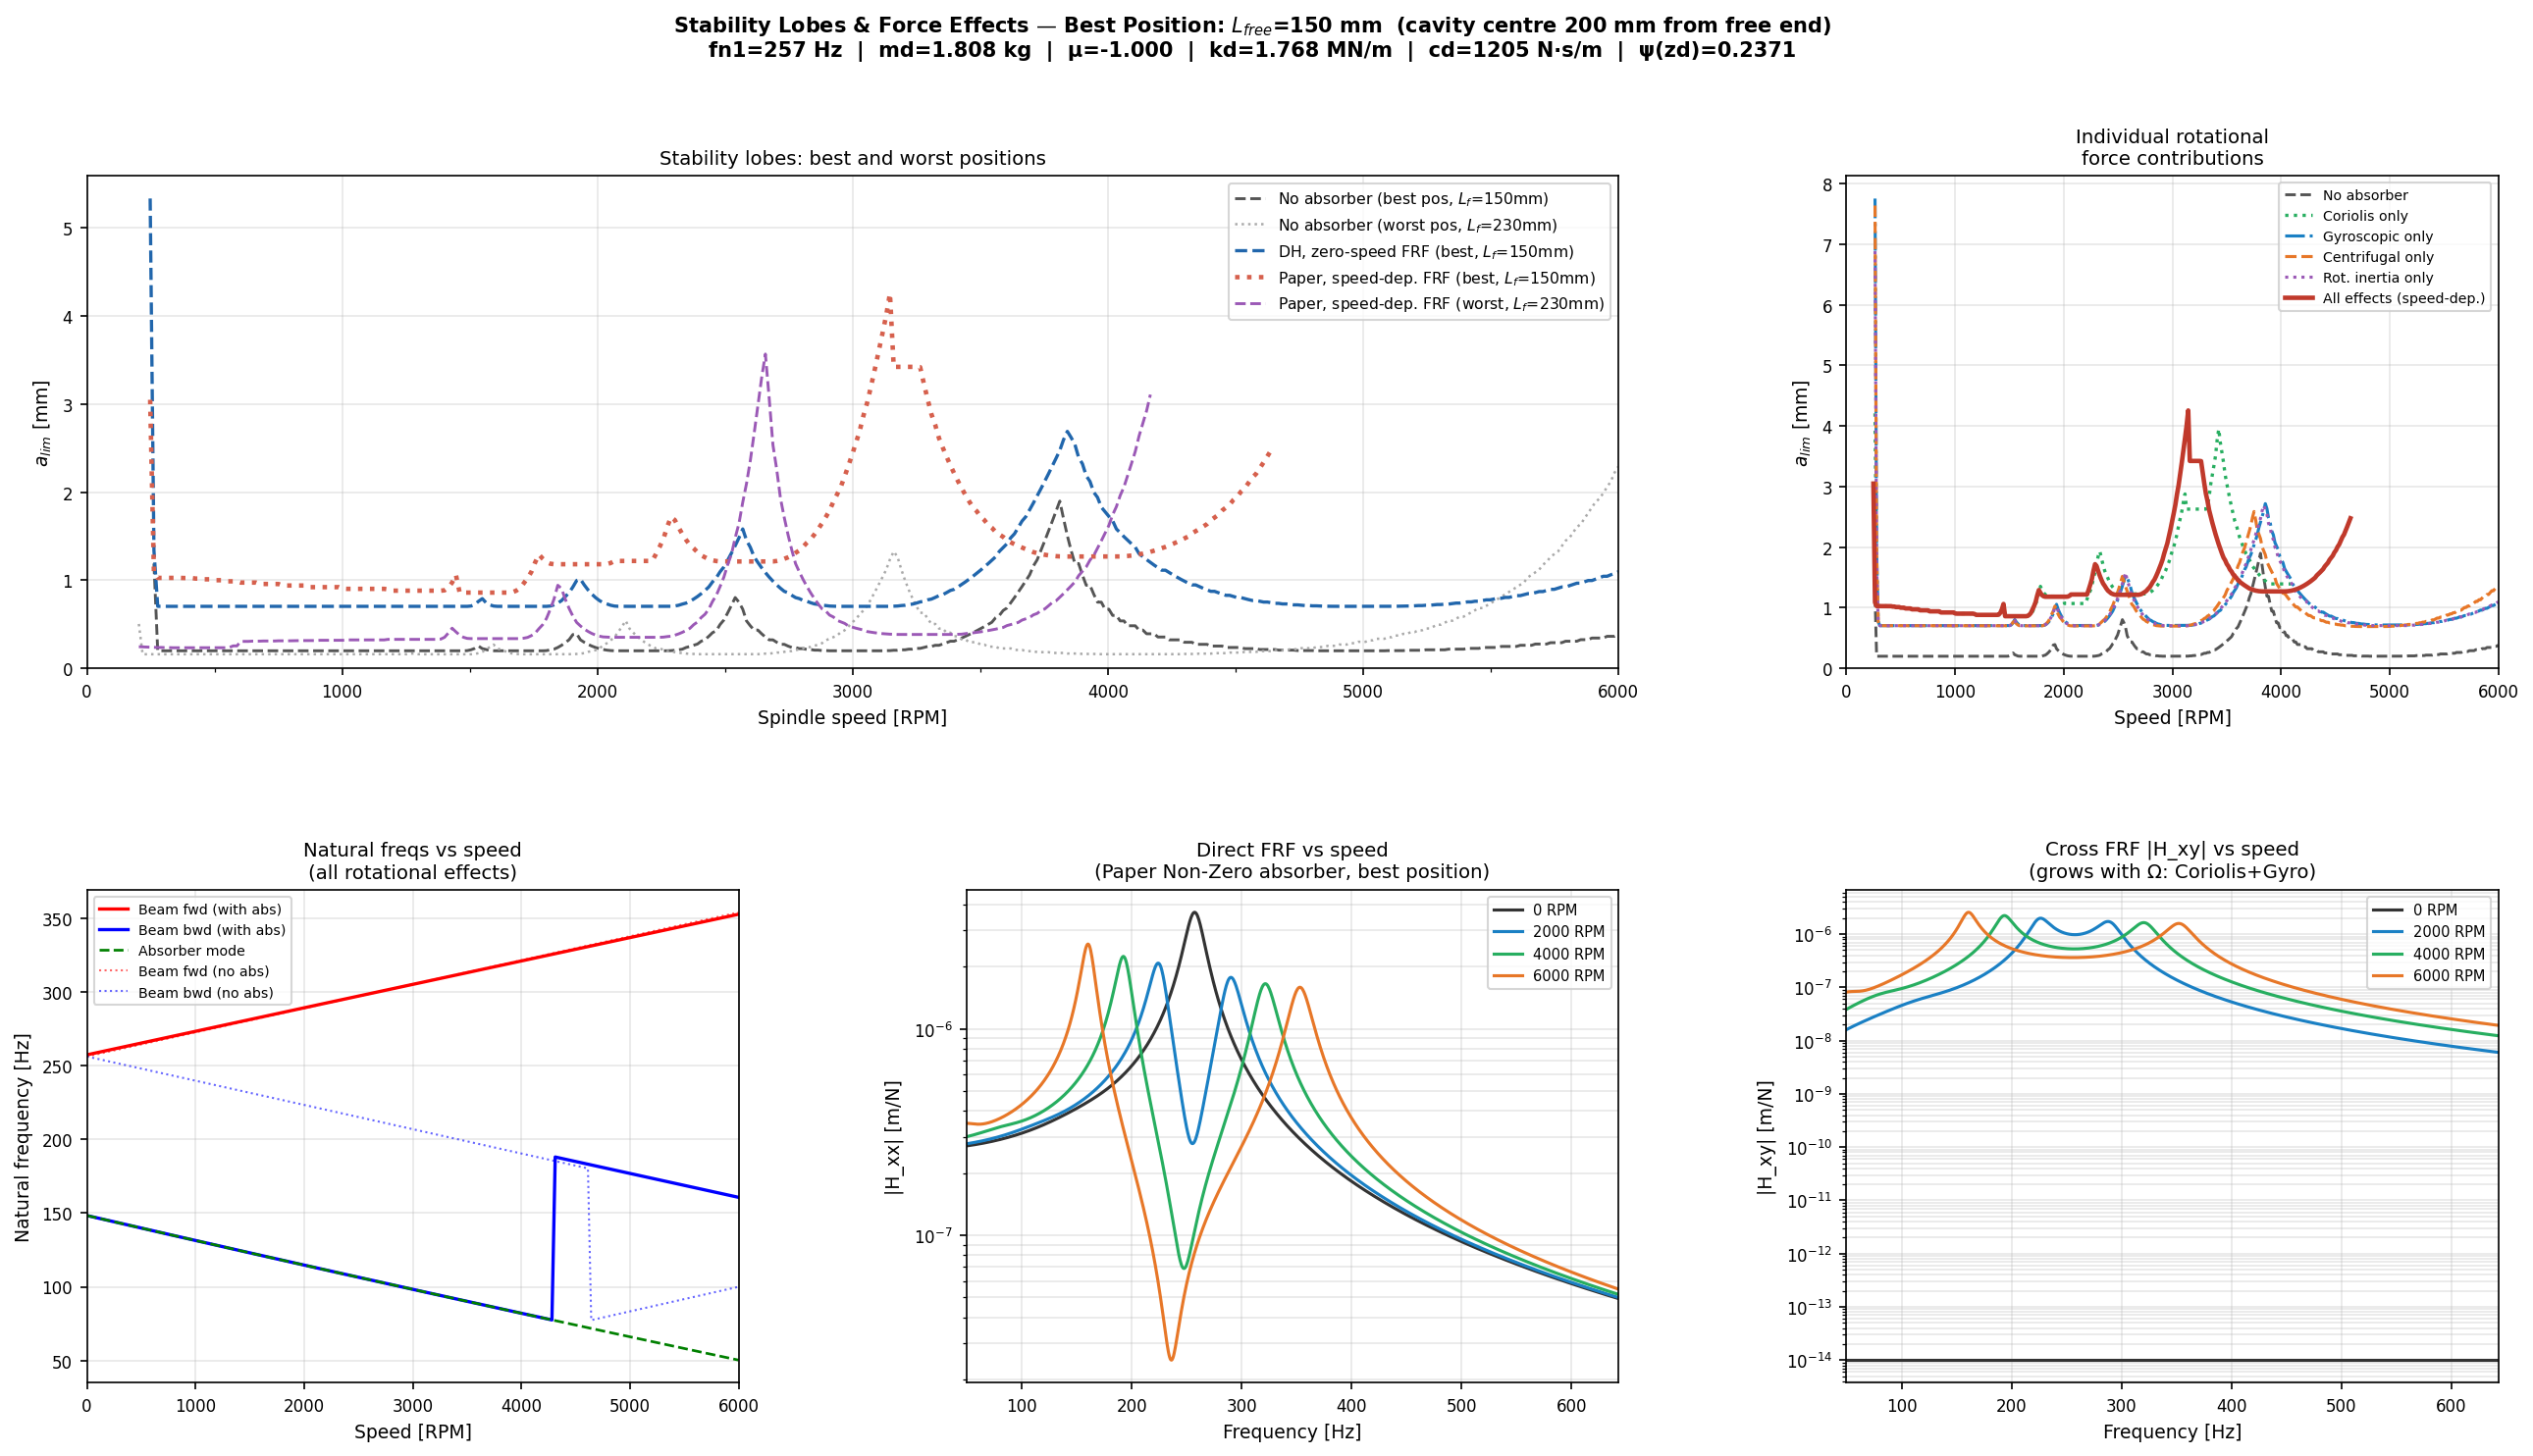

Saved → borebar_param1_free_end_lobes.png


In [ ]:
# ── FIG 2 : Full stability lobes (best/worst/ref) + force effects ─────────
fig2 = plt.figure(figsize=(18, 10))
fig2.suptitle(
    f"Stability Lobes & Force Effects — Best Position: "
    f"$L_{{free}}$={L_free_best*1e3:.0f} mm  "
    f"(cavity centre {(L_free_best+L4/2)*1e3:.0f} mm from free end)\n"
    f"fn1={best['fn1']:.0f} Hz  |  md={md:.3f} kg  |  "
    f"μ={best['mu']:.3f}  |  "
    f"kd={best['kd_dh']/1e6:.3f} MN/m  |  cd={best['cd_dh']:.0f} N·s/m  |  "
    f"ψ(zd)={best['PSI_zd']:.4f}",
    fontsize=10, fontweight="bold", y=1.01)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35,
                         left=0.06, right=0.97, top=0.90, bottom=0.08)

# 2a — full lobes: best vs worst vs no-absorber
ax2a = fig2.add_subplot(gs2[0, 0:2])
lobe_sets = [
    (best['env_na'],   f"No absorber (best pos, $L_f$={best['L_free']*1e3:.0f}mm)",   "#555","--",1.4),
    (worst['env_na'],  f"No absorber (worst pos, $L_f$={worst['L_free']*1e3:.0f}mm)", "#AAA",":",1.2),
    (best['env_dh0'],  f"DH, zero-speed FRF (best, $L_f$={best['L_free']*1e3:.0f}mm)","#2166AC","--",1.6),
    (best['env_dhS'],  f"Paper, speed-dep. FRF (best, $L_f$={best['L_free']*1e3:.0f}mm)","#D6604D",":",2.2),
    (worst['env_dhS'], f"Paper, speed-dep. FRF (worst, $L_f$={worst['L_free']*1e3:.0f}mm)","#9B59B6","--",1.4),
]
for env, lbl, col, ls, lw in lobe_sets:
    ax2a.plot(N_grid, env, color=col, ls=ls, lw=lw, label=lbl)
ax2a.set_xlim(0, 6000);  ax2a.set_ylim(0, None)
ax2a.set_xlabel("Spindle speed [RPM]");  ax2a.set_ylabel("$a_{lim}$ [mm]")
ax2a.set_title("Stability lobes: best and worst positions")
ax2a.legend(fontsize=7.5, ncol=1);  ax2a.grid(True, alpha=0.3)
ax2a.xaxis.set_major_locator(plt.MultipleLocator(1000))
ax2a.xaxis.set_minor_locator(plt.MultipleLocator(500))

# 2b — force effect contributions at best position
ax2b = fig2.add_subplot(gs2[0, 2])
force_cfg = [
    (best['env_na'],  "No absorber",              "#555","--",1.4),
    (env_cor,         "Coriolis only",             "#27AE60",":",1.6),
    (env_gyro,        "Gyroscopic only",           "#1A80C4","-.",1.5),
    (env_cent,        "Centrifugal only",          "#E77728","--",1.5),
    (env_ri,          "Rot. inertia only",         "#9B59B6",":",1.5),
    (best['env_dhS'], "All effects (speed-dep.)",  "#C0392B","-",2.2),
]
for env, lbl, col, ls, lw in force_cfg:
    ax2b.plot(N_grid, env, color=col, ls=ls, lw=lw, label=lbl)
ax2b.set_xlim(0, 6000);  ax2b.set_ylim(0, None)
ax2b.set_xlabel("Speed [RPM]");  ax2b.set_ylabel("$a_{lim}$ [mm]")
ax2b.set_title("Individual rotational\nforce contributions")
ax2b.legend(fontsize=6.8);  ax2b.grid(True, alpha=0.3)

# 2c — nat freqs vs speed
ax2c = fig2.add_subplot(gs2[1, 0])
ax2c.plot(speeds_plot, fw_abs, 'r-',  lw=1.6, label='Beam fwd (with abs)')
ax2c.plot(speeds_plot, bw_abs, 'b-',  lw=1.6, label='Beam bwd (with abs)')
ax2c.plot(speeds_plot, ab_abs, 'g--', lw=1.3, label='Absorber mode')
ax2c.plot(speeds_plot, fw_na,  'r:',  lw=1.0, alpha=0.6, label='Beam fwd (no abs)')
ax2c.plot(speeds_plot, bw_na,  'b:',  lw=1.0, alpha=0.6, label='Beam bwd (no abs)')
ax2c.set_xlabel("Speed [RPM]");  ax2c.set_ylabel("Natural frequency [Hz]")
ax2c.set_title("Natural freqs vs speed\n(all rotational effects)")
ax2c.set_xlim(0,6000); ax2c.legend(fontsize=6.8); ax2c.grid(True, alpha=0.3)

# 2d — direct FRF
ax2d = fig2.add_subplot(gs2[1, 1])
for i, rpm in enumerate(frf_speeds):
    ax2d.semilogy(freqs_frf, FRF_d[i], color=clrs_frf[i], lw=1.5, label=f'{rpm} RPM')
ax2d.set_xlabel("Frequency [Hz]");  ax2d.set_ylabel("|H_xx| [m/N]")
ax2d.set_title("Direct FRF vs speed\n(Paper Non-Zero absorber, best position)")
ax2d.set_xlim(50, 2.5*best['fn1']);  ax2d.legend(fontsize=7)
ax2d.grid(True, which='both', alpha=0.3)

# 2e — cross FRF (Coriolis/Gyro coupling grows with speed)
ax2e = fig2.add_subplot(gs2[1, 2])
for i, rpm in enumerate(frf_speeds):
    ax2e.semilogy(freqs_frf, np.clip(FRF_c[i],1e-14,None),
                  color=clrs_frf[i], lw=1.5, label=f'{rpm} RPM')
ax2e.set_xlabel("Frequency [Hz]");  ax2e.set_ylabel("|H_xy| [m/N]")
ax2e.set_title("Cross FRF |H_xy| vs speed\n(grows with Ω: Coriolis+Gyro)")
ax2e.set_xlim(50, 2.5*best['fn1']);  ax2e.legend(fontsize=7)
ax2e.grid(True, which='both', alpha=0.3)

plt.tight_layout()
fig2.savefig(
    PLOT_DIR / f"Full stability lobes{RUN_ID}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print(f"Saved → borebar_param1_free_end_lobes.png")

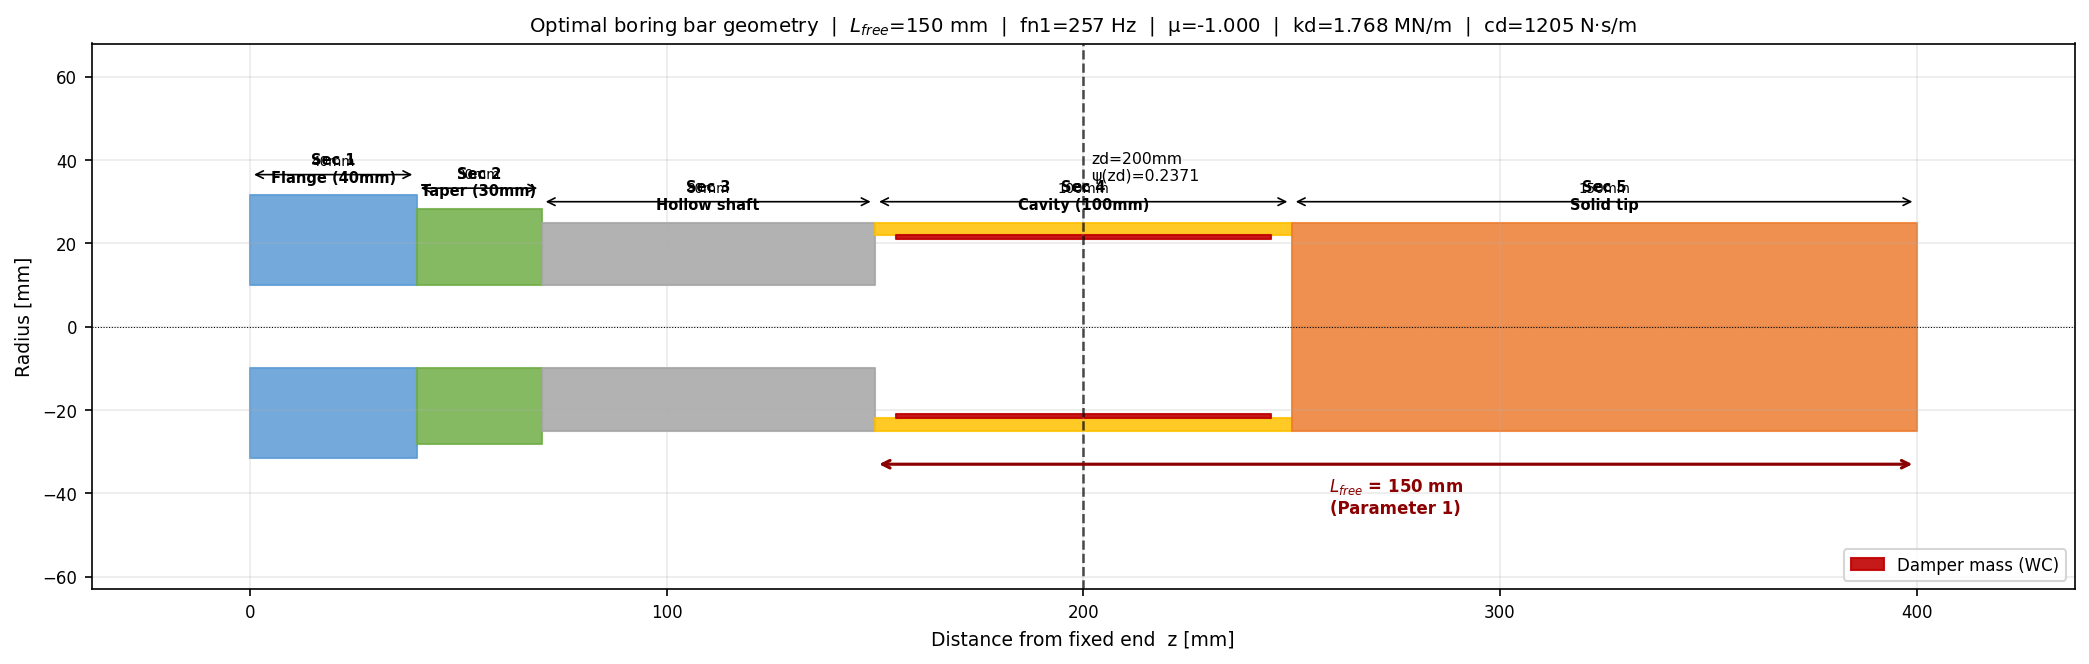

Saved → borebar_param1_free_end_geometry.png


In [ ]:
import numpy as np
# __ FIG 3 : Geometry schematic ────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 4.5))
ax3.set_xlim(-5, L_total*1e3 + 5)
ax3.set_aspect('equal', adjustable='datalim')

# Ensure 'mu' and 'zeta_dh' are available in 'best' for the title,
# re-calculating them if necessary based on the formula from xmCyJ0ZKipWw.
# This addresses a potential KeyError if these keys are unexpectedly missing.
if 'mu' not in best or 'zeta_dh' not in best:
    # Assuming kd_dh is always present and non-zero based on previous successful executions
    best['mu'] = 1/best['kd_dh']-1
    # Calculate zeta_dh, handling potential non-positive argument for sqrt if mu < -1
    arg = 3.0*best['mu'] / (8.0*(1.0+best['mu']))
    if arg >= 0:
        best['zeta_dh'] = np.sqrt(arg)
    else:
        best['zeta_dh'] = np.nan # Or handle as appropriate if mu leads to invalid zeta_dh

zb  = best['zb']
sec_col   = ['#5B9BD5','#70AD47','#A5A5A5','#FFC000','#ED7D31']
sec_names = ['Sec 1\nFlange (40mm)', 'Sec 2\nTaper (30mm)',
             'Sec 3\nHollow shaft', 'Sec 4\nCavity (100mm)',
             'Sec 5\nSolid tip']
D_outs = [D1_out, (D1_out+D_main)/2, D_main, D_main, D_main]
D_ins  = [di_body, di_body, di_body, di_cav, 0.0]

for k in range(5):
    zs = zb[k]*1e3;  ze = zb[k+1]*1e3
    ro = D_outs[k]*500;  ri = D_ins[k]*500
    ax3.fill_between([zs, ze],  [ro, ro],  [ri, ri],  color=sec_col[k], alpha=0.85)
    ax3.fill_between([zs, ze], [-ri,-ri], [-ro,-ro], color=sec_col[k], alpha=0.85)
    cx = (zs+ze)/2
    ax3.text(cx, ro+2.5, sec_names[k], ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax3.annotate('', xy=(ze, ro+5), xytext=(zs, ro+5),
                 arrowprops=dict(arrowstyle='<->', color='k', lw=0.8))
    ax3.text(cx, ro+6.5, f"{ze-zs:.0f}mm", ha='center', va='bottom', fontsize=6.5)

# Damper mass
zd_mm   = best['zd']*1e3
Lhalf   = L_damp*500
ax3.fill_between([zd_mm-Lhalf, zd_mm+Lhalf],
                 [d_damp*500, d_damp*500], [di_cav*500, di_cav*500],
                 color='#C00000', alpha=0.9, label='Damper mass (WC)')
ax3.fill_between([zd_mm-Lhalf, zd_mm+Lhalf],
                 [-di_cav*500, -di_cav*500], [-d_damp*500, -d_damp*500],
                 color='#C00000', alpha=0.9)

# L_free annotation (from free end to cavity start)
zs_cav = zb[3]*1e3
ax3.annotate('', xy=(L_total*1e3, -33), xytext=(zs_cav, -33),
             arrowprops=dict(arrowstyle='<->', color='darkred', lw=1.5))
ax3.text((L_total*1e3 + zs_cav)/2, -36,
         f"$L_{{free}}$ = {best['L_free']*1e3:.0f} mm\n(Parameter 1)",
         ha='center', va='top', fontsize=8, color='darkred', fontweight='bold')

# zd annotation
ax3.axvline(zd_mm, color='k', ls='--', lw=1.2, alpha=0.7)
ax3.text(zd_mm+2, D_main*500+10, f"zd={zd_mm:.0f}mm\nψ(zd)={best['PSI_zd']:.4f}",
         fontsize=7.5, color='k')

ax3.axhline(0, color='k', lw=0.5, ls=':')
ax3.set_xlabel("Distance from fixed end  z [mm]")
ax3.set_ylabel("Radius [mm]")
ax3.set_ylim(-45, 50)
ax3.set_title(
    f"Optimal boring bar geometry  |  $L_{{free}}$={best['L_free']*1e3:.0f} mm  |  "
    f"fn1={best['fn1']:.0f} Hz  |  μ={best['mu']:.3f}  |  "
    f"kd={best['kd_dh']/1e6:.3f} MN/m  |  cd={best['cd_dh']:.0f} N·s/m",
    fontsize=9.5)
ax3.legend(fontsize=8, loc='lower right');  ax3.grid(True, alpha=0.25)

plt.tight_layout()
fig3.savefig(
    PLOT_DIR / f"borebar_param1_free_end_geometry{RUN_ID}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print(f"Saved → borebar_param1_free_end_geometry.png")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 12.  RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*75)
print("COMPLETE RESULTS TABLE — Position from Free End")
print("="*75)
print(f"  {'L_free[mm]':>11} {'L3[mm]':>7} {'zd_ctr[mm]':>11} "
      f"{'dist_ctr_free[mm]':>18} {'fn1[Hz]':>8} {'Mm[kg]':>7} "
      f"{'ψ(zd)':>7} {'μ':>6} {'kd[MN/m]':>9} {'cd[Ns/m]':>9} "
      f"{'al_na[mm]':>10} {'al_DH[mm]':>10} {'ratio':>7}")
print("-"*130)
for r_ in results:
    dist_ctr_free = r_['L_free']*1e3 + L4/2*1e3
    print(f"  {r_['L_free']*1e3:11.1f} {r_['L3']*1e3:7.0f} {r_['zd']*1e3:11.0f} "
          f"{dist_ctr_free:18.0f} {r_['fn1']:8.1f} {r_['Mm']:7.4f} "
          f"{r_['PSI_zd']:7.4f} {1/r_['kd_dh']-1:6.3f} {r_['kd_dh']/1e6:9.4f} {r_['cd_dh']:9.1f} "
          f"{r_['alim_na']*1e3:10.4f} {r_['alim_dhS']*1e3:10.4f} {r_['ratio_dhS']:7.2f}×")

print(f"\n{'='*75}")
print("OPTIMAL DESIGN SUMMARY")
print(f"{'='*75}")
print(f"  Parameter 1 (position from free end): L_free = {best['L_free']*1e3:.1f} mm")
print(f"  Equivalent solid tip length L5      = {best['L5']*1e3:.1f} mm")
print(f"  Equivalent L3 (hollow before cavity)= {best['L3']*1e3:.1f} mm")
print(f"  Cavity: [{best['zb'][3]*1e3:.0f}, {best['zb'][4]*1e3:.0f}] mm from fixed end")
print(f"  Absorber centre zd                  = {best['zd']*1e3:.0f} mm from fixed end")
print(f"  Absorber centre from free end        = {(best['L_free']+L4/2)*1e3:.0f} mm")
print(f"")
print(f"  fn1  = {best['fn1']:.1f} Hz")
print(f"  Mm   = {best['Mm']:.4f} kg")
print(f"  ψ(zd)= {best['PSI_zd']:.4f}")
print(f"  md   = {md:.4f} kg  (WC)")
print(f"  μ    = {best['mu']:.4f}")
print(f"")
print(f"  Paper kd = {best['kd_dh']/1e6:.4f} MN/m")
print(f"  Paper cd = {best['cd_dh']:.2f} N·s/m  (ζ = {best['zeta_dh']:.3f})")
print(f"")
print(f"  Min alim — no absorber    : {best['alim_na']*1e3:.4f} mm")
print(f"  Min alim — DH zero-speed  : {best['alim_dh0']*1e3:.4f} mm  ({best['ratio_dh0']:.2f}×)")
print(f"  Min alim — DH speed-dep.  : {best['alim_dhS']*1e3:.4f} mm  ({best['ratio_dhS']:.2f}×)")
print(f"")
print(f"SAVED FIGURES:")
print(f"  borebar_param1_free_end_sweep.png    — complete position sweep")
print(f"  borebar_param1_free_end_lobes.png    — stability lobes + force effects")
print(f"  borebar_param1_free_end_geometry.png — geometry schematic")


COMPLETE RESULTS TABLE — Position from Free End
   L_free[mm]  L3[mm]  zd_ctr[mm]  dist_ctr_free[mm]  fn1[Hz]  Mm[kg]   ψ(zd)      μ  kd[MN/m]  cd[Ns/m]  al_na[mm]  al_DH[mm]   ratio
----------------------------------------------------------------------------------------------------------------------------------
        150.0      80         200                200    257.0  1.4757  0.2371 -1.000    1.7677    1205.3   198.5879   859.4247    4.33×
        157.3      73         193                207    252.7  1.4976  0.2173 -1.000    0.7589    1721.1   194.8940   630.9590    3.24×
        164.5      65         185                215    248.5  1.5197  0.1988 -1.000    0.9016    1181.2   191.1442   520.7179    2.72×
        171.8      58         178                222    244.3  1.5415  0.1813 -1.000    1.2093     910.4   187.4233   466.3563    2.49×
        179.1      51         171                229    240.2  1.5629  0.1648 -1.000    1.5103    1146.2   183.7442   485.5396    2.64×
     